Our expectation with the original LEMBAS is as follows:
1) It cannot handle multiple cell types
2) It cannot account for the dispersion within a cluster at single-cell resolution, and will output the centroid of a cluster instead.

Next, we want to see whether scLEMBAS can capture single-cell resolution data.

In [1]:
import os
from itertools import combinations

import numpy as np
import pandas as pd

import anndata
import scanpy as sc
from sklearn.neighbors import NearestCentroid
from scipy.spatial.distance import cdist, pdist, squareform

import torch
import torch.nn as nn

import matplotlib.pyplot as plt
import seaborn as sns
import plotnine as p9
import patchworklib as pw

import sys

sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import parse_network, io
from scLEMBAS.model.scl import SignalingModel
from scLEMBAS.model.train import TrainCat, TrainSC
from scLEMBAS.plotting import plot_embedding

<Figure size 100x100 with 0 Axes>

In [2]:
n_cores = 12
os.environ["OMP_NUM_THREADS"] = str(n_cores)
os.environ["MKL_NUM_THREADS"] = str(n_cores)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cores)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(n_cores)
os.environ["NUMEXPR_NUM_THREADS"] = str(n_cores)

seed = 888

device = "cuda" if torch.cuda.is_available() else "cpu"

data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'
models_path = os.path.join(data_path, 'processed', 'models')
if not os.path.isdir(models_path):
    os.mkdir(models_path)

Load files:

In [3]:
tf_adata = io.read_tfad(file_name = os.path.join(data_path, 'processed', 'ID_tf_activity.h5ad'))
adata = sc.read_h5ad(os.path.join(data_path, 'processed', 'expr_scored.h5ad'))
sn_ppis = pd.read_csv(os.path.join(data_path, 'processed', 'sn_ppis.csv'), index_col = 0)

In [4]:
source_label = 'source_genesymbol'
target_label = 'target_genesymbol'
weight_label = 'mode_of_action'
stimulation_label = 'consensus_stimulation'
inhibition_label = 'consensus_inhibition'

Scale the expression data for the VAE to better handle:

In [5]:
expr = adata[:, adata.var[adata.var['highly_variable']].index] # filter for HVGs for simplicity
expr = sc.pp.scale(expr, copy = True)

The interactions include the following input ligands:

In [6]:
tf_labels = tf_adata.var.index.unique().tolist()

ligand_labels = tf_adata.obs['sample'].unique().tolist()
ligand_labels = [(l[0] + l[1:].lower()).replace('-', '') for l in ligand_labels] # mouse naming convention

all_nodes = sn_ppis[source_label].tolist() + sn_ppis[target_label].tolist()
input_ligands_available = sorted(set(ligand_labels).intersection(all_nodes))
print(*input_ligands_available, sep = ', ')

Egf, Gdnf, Hgf, Ifng, Il10, Il11, Il13, Il15, Il1a, Il1b, Il2, Il21, Il4, Il5, Il6, Il7, Il9, Lif, Osm, Tslp


# Explore performance on TF activity

In [7]:
group_label = 'TF_clusters' # ordered cateogry in obs

## Scenario 3:

In [8]:
model_no = 3

The simplest scenario is:
- 2 cell type
- 1 ligand
- Binary ligand exposure (0 or 1)
- Exposure leads to distinct clusters in TF activity space

For now, we simply use visualization to identify the most distinct clusters:

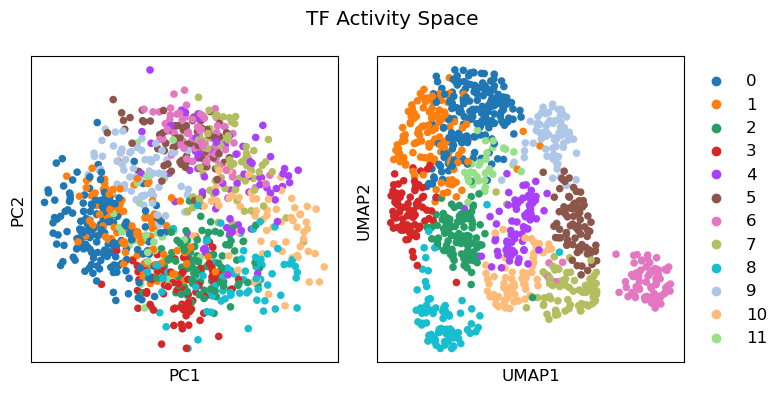

In [9]:
fig, ax = plt.subplots(ncols = 2, figsize = (8, 4))
sc.pl.pca(tf_adata, color='TF_clusters', ax = ax[0], show = False)
ax[0].legend().set_visible(False)
ax[0].set_title('')
sc.pl.umap(tf_adata, color='TF_clusters', ax = ax[1], show = False)
ax[1].set_title('')

fig.suptitle('TF Activity Space')

fig.tight_layout()
# plt.savefig(fname = os.path.join(data_path, 'figures', 'tf_celltype_umap.png'), 
#             transparent = True, 
#             bbox_inches = 'tight')
plt.show()


Based on these results, we choose clusters ...:

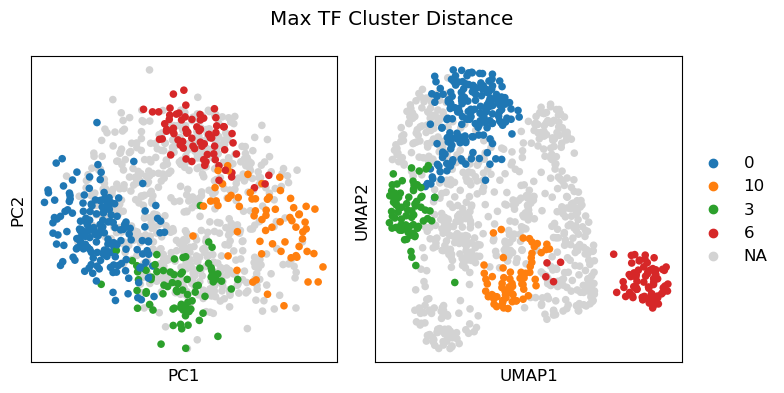

In [10]:
max_clusters = ['0', '10', '3', '6']
viz_adata = tf_adata.copy()
viz_adata.obs[group_label + '_color'] = pd.Categorical(viz_adata.obs[group_label], 
                                                       categories = max_clusters, 
                                                       ordered = True)
fig, ax = plt.subplots(ncols = 2, figsize = (8, 4))
sc.pl.pca(viz_adata, color=group_label + '_color', ax = ax[0], show = False)
ax[0].legend().set_visible(False)
ax[0].set_title('')
sc.pl.umap(viz_adata, color=group_label + '_color', ax = ax[1], show = False)
ax[1].set_title('')

fig.suptitle('Max TF Cluster Distance')

fig.tight_layout()
# plt.savefig(fname = os.path.join(data_path, 'figures', 'tf_celltype_umap.png'), 
#             transparent = True, 
#             bbox_inches = 'tight')
plt.show()


Based on these results, let's say that cluster 9 is unstimulated, and cluster 15 is stimulated. 

In [11]:
max_clusters = ['0', '10', '3', '6']

In [12]:
np.random.seed(seed)
selected_ligand = np.random.choice(input_ligands_available, 1)[0]
print('The selected ligand is: ' + selected_ligand)

subset_tf = tf_adata[tf_adata.obs.TF_clusters.isin(max_clusters)]
subset_tf.obs.TF_clusters.value_counts()

The selected ligand is: Il5


TF_clusters
0     178
3      77
6      74
10     66
Name: count, dtype: int64

For now, for speed, let's subset so that there are a smaller number of "samples" per condition:

In [13]:
sample_size = int(66)

barcodes = []
for cluster_label in subset_tf.obs.TF_clusters.unique():
    bc = subset_tf.obs[subset_tf.obs.TF_clusters == cluster_label].index
    np.random.seed(seed)
    barcodes += list(np.random.choice(bc, sample_size, replace = False))
subset_tf = subset_tf[barcodes, :]
subset_tf.obs.TF_clusters.value_counts()

TF_clusters
0     66
3     66
6     66
10    66
Name: count, dtype: int64

Next, let's initialize the model. 

Let's say clusters 4 and 5 are unstimulated, and 3 and 2 are stimulated
We assign clusters 3 and 4 as cell Type A, and 5 and 2 as cell type B.

In [14]:
ligand_input = pd.DataFrame(subset_tf.obs.TF_clusters.map({'0': 0, '6': 0, '3': 1, '10': 1}))
ligand_input.columns = [selected_ligand]


covariates = pd.DataFrame(subset_tf.obs.TF_clusters.map({'0': 'A', '3': 'A',
                                                        '6': 'B', '10': 'B'}))
covariates.columns = ['celltype']


tf_output = pd.DataFrame(subset_tf.X, index = subset_tf.obs.index, columns = subset_tf.var.index)


In [15]:
subset_tf.obs = pd.concat([covariates, ligand_input, pd.DataFrame({'TF_clusters': subset_tf.obs.TF_clusters})], axis = 1)


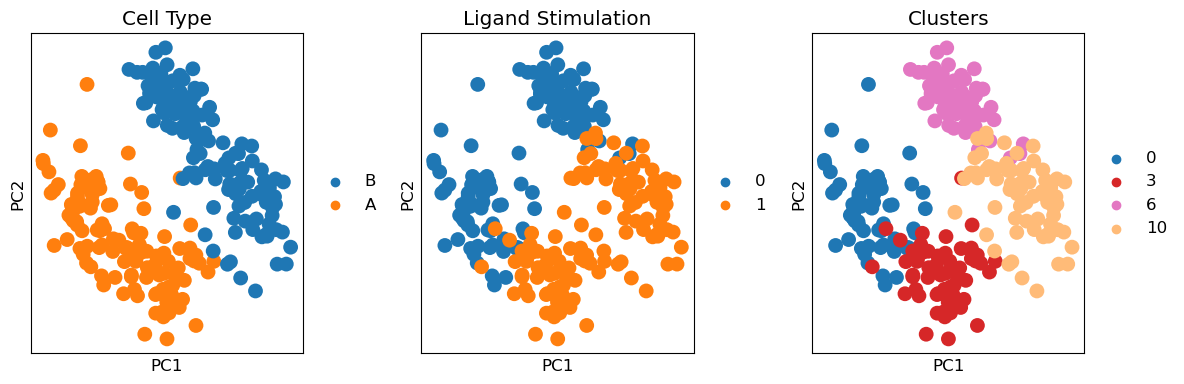

In [16]:
viz_adata = subset_tf.copy()
for col in viz_adata.obs.columns:
    viz_adata.obs[col] = pd.Categorical(viz_adata.obs[col],
                                        categories = viz_adata.obs[col].unique())


fig, ax = plt.subplots(ncols = 3, figsize = (12, 4))
sc.pl.pca(viz_adata, color='celltype', ax = ax[0], show = False)
ax[0].set_title('Cell Type')

sc.pl.pca(viz_adata, color=selected_ligand, ax = ax[1], show = False)
ax[1].set_title('Ligand Stimulation')

sc.pl.pca(viz_adata, color='TF_clusters', ax = ax[2], show = False)
ax[2].set_title('Clusters')


fig.tight_layout()
plt.show()


In [17]:
expr = expr[subset_tf.obs.index, :] # subset expression to the same

In [18]:
vae_n_hidden_nodes = [2500, 2000, 1500]
discriminator_n_hidden_nodes = [768, 512, 256]
me = 300 # max epochs

In [19]:
# linear scaling of inputs/outputs
projection_amplitude_in = 3
projection_amplitude_out = 1.2
# other parameters
bionet_params = {'target_steps': 100, 
                 'max_steps': 120, 
                 'exp_factor':50, 
                 'tolerance': 1e-5, 
                 'leak':1e-2, 
                'cat_max_norm': 1} 
vae_params = {'vae_batch_momentum': 0.01, 'vae_layer_norm': False, 'vae_dropout_rate': 0.1,
              'vae_activation_fn': nn.LeakyReLU,
              'vae_n_hidden_nodes': vae_n_hidden_nodes, 
              'vae_var_min': 1e-4}
bionet_params = {**bionet_params, **vae_params}

# training parameters
lr_params = {'max_epochs': me, 'maximum_learning_rate': 2e-4, 'minimum_learning_rate': 2e-5,
                 'lr_restart_epoch': int(me/5), 'reset_optimizer_epoch': 200, 
                'lr_decay': 0.9, 'lr_restart_factor': 1, 'warmup_epochs': int(me/10)}

other_params = {'train_batch_size': 2056, 'test_batch_size': 512, 'validation_batch_size': 512, 
                    'network_noise_scale': 10, 'gradient_noise_scale': 1e-9}

spectral_radius_params = {'n_probes_spectral': 5, 
                          'power_steps_spectral': 50, 
                          'subset_n_spectral': 10}
target_spectral_radius = 0.8

In [20]:
# regularization_params = {'input_lambda_L2': 1e-6, 'hidden_state_lambda_L2': 1e-6, 'bias_lambda_L2': 1e-6, 
#                              'output_lambda_L2': 1e-6, 
#                          'moa_lambda_L1': 0.1, #'ligand_lambda_L2': 1e-5, 
#                          'uniform_lambda_L2': 1e-4,  
#                          'uniform_max': (1/1.2), 
#                          'spectral_loss_factor': 1e-5, 
#                         'vae_lambda_l2': 1e-5, 
#                         'vae_scaling_KL': 1e-2}
regularization_params = {'input_lambda_L2': 0, 'hidden_state_lambda_L2': 0, 'bias_lambda_L2': 0, 
                             'output_lambda_L2': 0, 
                         'moa_lambda_L1': 0, #'ligand_lambda_L2': 1e-5, 
                         'uniform_lambda_L2': 0,  
                         'uniform_max': (1/1.2), 
                         'spectral_loss_factor': 0, 
                        'vae_lambda_l2': 0, 
                        'vae_scaling_KL': 0}

discriminator_params = {'batch_momentum': 0.01,
 'layer_norm': False,
 'dropout_rate': 0.1,
 'activation_fn': nn.LeakyReLU,
 'n_hidden_nodes': discriminator_n_hidden_nodes,
 'maximum_learning_rate': 2e-3,
 'minimum_learning_rate':2e-4,
 'lr_restart_epoch': int(me/5),
 'reset_optimizer_epoch': 200,
 'lr_decay': 0.9,
 'lr_restart_factor': 1,
 'warmup_epochs': int(me/10),
 'optimizer': torch.optim.Adam,
 'discriminator_lambda_L2': 0,#1e-05, 
                       'discriminator_penalty_weight': 1}

In [21]:
training_params = {**lr_params, **other_params, **regularization_params, **spectral_radius_params}

In [22]:
mod = SignalingModel(net = sn_ppis,
                     X_in = ligand_input,
                     y_out = tf_output, 
                     expr = expr.to_df(), 
                     covariates = subset_tf.obs,
                     categorical_covariate_keys = ['celltype'],
                     projection_amplitude_in = projection_amplitude_in, projection_amplitude_out = projection_amplitude_out,
                     weight_label = weight_label, source_label = source_label, target_label = target_label,
                     bionet_params = bionet_params, 
                     dtype = torch.float32, device = device, seed = seed)



In [23]:
# # get pca on on selected features
# subset_tf = subset_tf[:, mod.y_out.columns]
# embed_tf_activity(subset_tf)

Next, let's train the model:

In [24]:
# model setup
mod.input_layer.weights.requires_grad = False # don't learn scaling factors for the ligand input concentrations
mod.signaling_network.prescale_weights(target_radius = target_spectral_radius) # spectral radius

# training loop
trainer = TrainSC(mod = mod,
                   prediction_optimizer = torch.optim.Adam,
                   prediction_loss_fn = torch.nn.MSELoss(reduction='mean'),
                  discriminator_params = discriminator_params,
                   hyper_params = training_params,
                   train_split = {'train': 0.8, 'test': 0.2, 'validation': None}, 
                   train_seed = seed, 
                   track_test = True,
                   track_validation = False)
mod = trainer.train_model(verbose = True)

torch.save(obj=mod.state_dict(), f=os.path.join(models_path, 'model_' + str(model_no) + '_state_dict.pth'))
io.write_pickled_object(trainer,  os.path.join(models_path, 'trainer_' + str(model_no) + '.pickle'))

  0%|▏                                        | 1/300 [00:00<02:32,  1.96it/s]

i=0, l(tr)=0.23315, l(te)=0.22416, s=0.26358, r=0.00002, v=0.00000


  1%|▌                                        | 4/300 [00:01<01:28,  3.33it/s]

i=3, l(tr)=0.23106, l(te)=0.22384, s=0.24834, r=0.00004, v=0.00000


  2%|▉                                        | 7/300 [00:02<01:20,  3.65it/s]

...

i=294, l(tr)=0.01721, l(te)=0.02572, s=0.31401, r=0.00010, v=0.00000


 99%|██████████████████████████████████████▋| 298/300 [01:21<00:00,  3.83it/s]

i=297, l(tr)=0.01682, l(te)=0.02484, s=0.31197, r=0.00009, v=0.00000


100%|███████████████████████████████████████| 300/300 [01:21<00:00,  3.67it/s]


Training ran in: 1 min 21.76 sec


In [25]:
trainer = io.read_pickled_object(os.path.join(models_path, 'trainer_' + str(model_no) + '.pickle'))
mod = trainer.mod
train_stats_df = trainer.stats['train'].copy()
test_stats_df = trainer.stats['test'].copy()

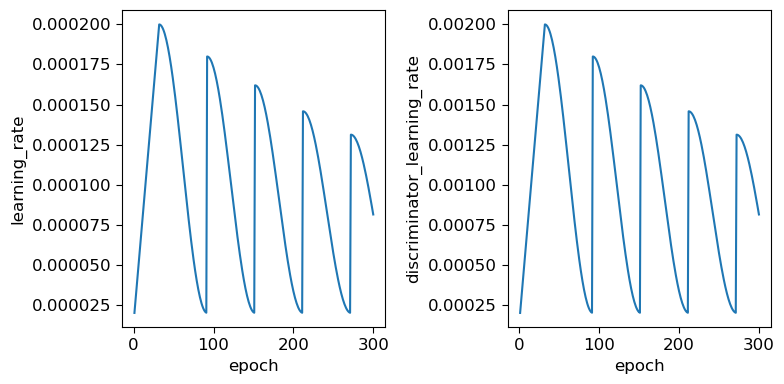

In [29]:
fig, ax = plt.subplots(ncols = 2, figsize = (8, 4))

sns.lineplot(data = train_stats_df, x = 'epoch', y = 'learning_rate', ax = ax[0])
sns.lineplot(data = train_stats_df, x = 'epoch', y = 'discriminator_learning_rate', ax = ax[1])
fig.tight_layout()

Text(0.5, 1.0, 'Train Loss - with Adverserial')

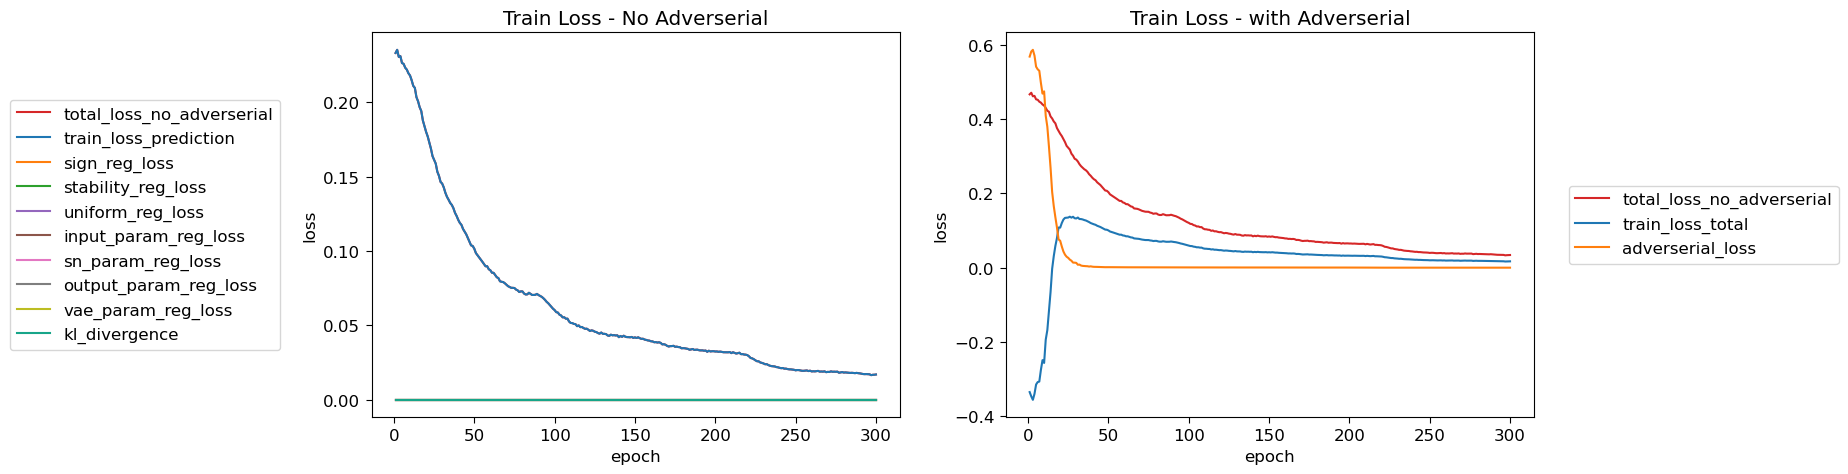

In [30]:
fig, ax = plt.subplots(ncols = 2, figsize = (15,5))

palette = sns.color_palette([
    "#d62728",  # Red
    "#1f77b4",  # Blue
    "#ff7f0e",  # Orange
    "#2ca02c",  # Green
    "#9467bd",  # Purple
    "#8c564b",  # Brown
    "#e377c2",  # Pink
    "#7f7f7f",  # Gray
    "#bcbd22",  # Olive
    "#17a589",  #  Teal 
    "#6baed6",  # light blue
    "#ff9896"   # Light red
])

# # plot 1: no adverserial
loss_cols_main = [
       'train_loss_prediction', 'sign_reg_loss',
       'stability_reg_loss', 'uniform_reg_loss', 'input_param_reg_loss',
       'sn_param_reg_loss', 'output_param_reg_loss', 'vae_param_reg_loss', 'kl_divergence']

viz_df = train_stats_df[['epoch'] + loss_cols_main].copy()
viz_df['total_loss_no_adverserial'] = viz_df[loss_cols_main].sum(axis = 1)
viz_df = viz_df.melt(id_vars = ['epoch'], var_name = 'loss_type', value_name = 'loss')
viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered = True, categories=['total_loss_no_adverserial'] + loss_cols_main)

sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette = palette, ax = ax[0])
# ax[0].set_yscale('log')
ax[0].legend(loc='center left', bbox_to_anchor=(-0.7, 0.5))
ax[0].set_title('Train Loss - No Adverserial')


loss_cols = ['train_loss_total'] + loss_cols_main + ['adverserial_loss']
viz_df = train_stats_df[['epoch'] + loss_cols].copy()
viz_df['total_loss_no_adverserial'] = viz_df[loss_cols].sum(axis = 1)
viz_df.drop(columns = loss_cols_main, inplace = True)
viz_df = viz_df.melt(id_vars = ['epoch'], var_name = 'loss_type', value_name = 'loss')
viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered = True, categories=['total_loss_no_adverserial', 'train_loss_total', 'adverserial_loss'])

sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette=palette, ax = ax[1])
# ax[0].set_yscale('log')
ax[1].legend(loc='center left', bbox_to_anchor=(1.05, 0.5))
ax[1].set_title('Train Loss - with Adverserial')
# ax[0].set_yscale('symlog')


Text(0.5, 1.0, 'Discriminator Loss')

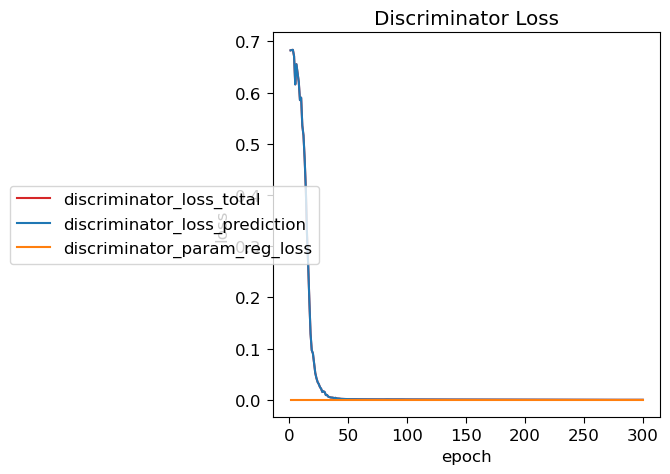

In [31]:
fig, ax = plt.subplots(ncols = 1, figsize = (5,5))


loss_cols_disc = ['discriminator_loss_total',
       'discriminator_loss_prediction', 'discriminator_param_reg_loss']
viz_df = train_stats_df[['epoch'] + loss_cols_disc].copy()
viz_df = viz_df.melt(id_vars = ['epoch'], var_name = 'loss_type', value_name = 'loss')
viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered = True, categories=loss_cols_disc)

sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette = palette, ax = ax)
# ax[0].set_yscale('log')
ax.legend(loc='center left', bbox_to_anchor=(-0.7, 0.5))
ax.set_title('Discriminator Loss')


''

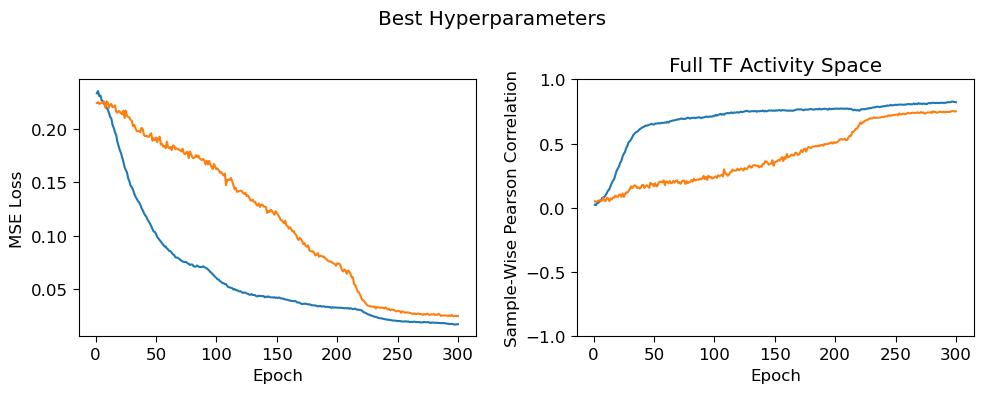

In [39]:
fig, ax = plt.subplots(ncols = 2, figsize = (10, 4))

g = sns.lineplot(data = train_stats_df, x = 'epoch', y = 'train_loss_prediction', ax = ax[0])
g = sns.lineplot(data = test_stats_df, x = 'epoch', y = 'test_loss_prediction', ax = ax[0])
ax[0].set_ylabel('MSE Loss')
ax[0].set_xlabel('Epoch')
# ax[0].set_yscale('log')

g = sns.lineplot(data = train_stats_df, x = 'epoch', y = 'train_pearson', ax = ax[1])
g = sns.lineplot(data = test_stats_df, x = 'epoch', y = 'test_pearson', ax = ax[1])
ax[1].set_title('Full TF Activity Space')
ax[1].set_ylabel('Sample-Wise Pearson Correlation')
ax[1].set_ylim([-1,1])
ax[1].set_xlabel('Epoch')

fig.suptitle('Best Hyperparameters')
fig.tight_layout()
;


Let's see what the train dataset will output:

In [40]:
# inputs
X_train = mod.df_to_tensor(trainer.X_train)
y_train = mod.df_to_tensor(trainer.y_train)
expr_train = mod.df_to_tensor(mod.expr.loc[trainer.X_train.index, :])
covariates_idx_train = mod.signaling_network.covariates_to_tensor(sample_ids = trainer.X_train.index)

# run prediction
mod.eval()
with torch.inference_mode():
    Y_hat, Y_full, biases = mod(X_in = X_train, covariates_idx = covariates_idx_train, expr = expr_train)
    bias_global, bias_mu, bias_log_sigma_squared = biases

# formatting
y_predicted = pd.DataFrame(Y_hat.cpu().detach().numpy())
y_predicted.index, y_predicted.columns = trainer.y_train.index, trainer.y_train.columns

In [41]:
pearsons = trainer.get_pearson_correlation(Y_hat, y_train, axis=1, return_mean=False)

''

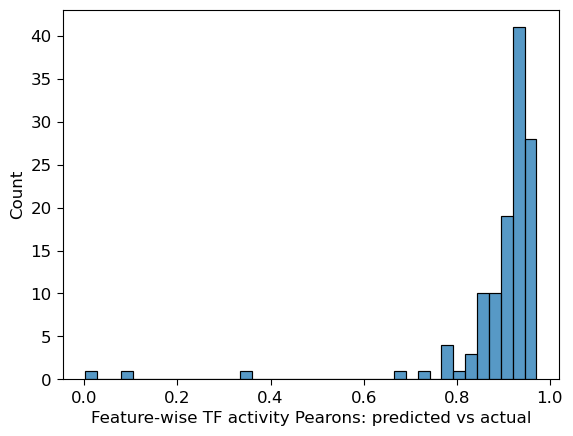

In [42]:
fig, ax = plt.subplots()
sns.histplot(pearsons, ax = ax)
ax.set_xlabel('Feature-wise TF activity Pearons: predicted vs actual')
;

In [43]:
pca_mod = subset_tf.uns['pca']['pca_mod']
rank = subset_tf.uns["pca"]['pca_rank']


md = subset_tf.obs
md['condition'] = md['celltype'].str.cat(md['Il5'].astype(str), sep='^')

X_pca = pd.DataFrame(subset_tf.obsm['X_pca'][:, :rank], 
                 index = subset_tf.obs.index, 
                columns = ['PC_{}'.format(i + 1) for i in range(rank)])
clf = NearestCentroid()
clf.fit(X_pca, md['condition'])
X_pca_centroids = pd.DataFrame(clf.centroids_, columns = clf.feature_names_in_, index = clf.classes_)

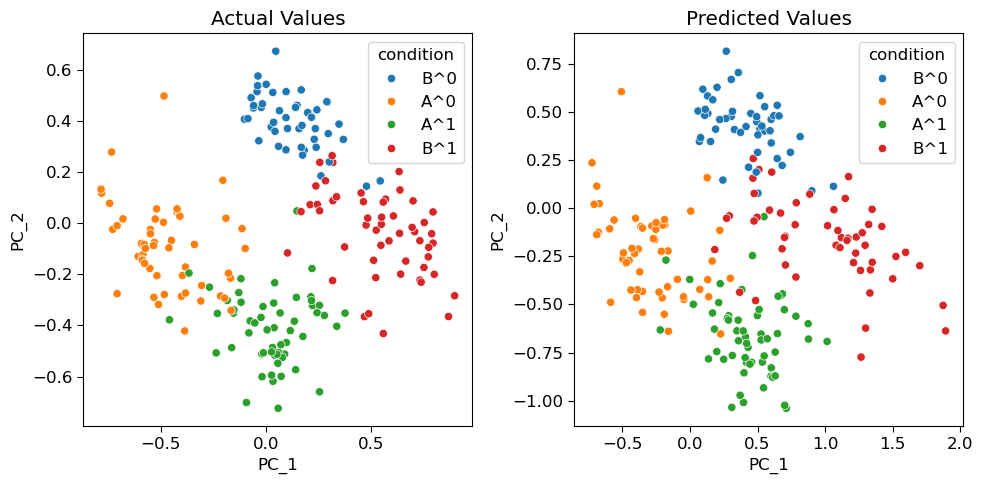

In [44]:
fig, ax = plt.subplots(figsize = (10,5), ncols = 2)


viz_df = pd.concat([X_pca.loc[trainer.y_train.index, :], pd.DataFrame(md.loc[trainer.y_train.index, 'condition'])], 
                  axis = 1)
sns.scatterplot(data = viz_df,x = 'PC_1', y = 'PC_2', hue = 'condition', ax = ax[0])
ax[0].set_title('Actual Values')


y_pred_pca = pd.DataFrame(pca_mod.transform(y_predicted), index = y_predicted.index, 
                          columns = ['PC_{}'.format(i + 1) for i in range(pca_mod.n_components)]).iloc[:, :rank]
viz_df = pd.concat([y_pred_pca, pd.DataFrame(md.loc[trainer.y_train.index, 'condition'])], 
                  axis = 1)
sns.scatterplot(data = viz_df,x = 'PC_1', y = 'PC_2', hue = 'condition', ax = ax[1])
ax[1].set_title('Predicted Values')

fig.tight_layout()